# Tutorial: Generative Models for Single-Particle Aerosol Measurements

This hands-on tutorial accompanies the notes on
[generative modeling](generativemodels.ipynb),
[GANs and diffusion models](gansdiffusion.ipynb), and
[VAEs](vaes.ipynb). We put all three architectures to work on the same real
instrument data set and ask three different questions of it.

The data come from the **Single Particle Soot Photometer (SP2)**, a specialized
research instrument used to measure aerosols (small particulate matter) during
airborne research field campaigns. Aerosol particles that strongly absorb
light, such as black carbon (also known as soot) and some mineral dusts and iron
oxide particles, can have important effects on climate. Quantifying the mass of
these aerosols in the atmosphere is important for understanding the role they
play in warming the atmosphere locally. The SP2 has traditionally been used to
measure black carbon, the most important absorbing aerosol in terms of its
effects on climate, but it can also detect other types of aerosol particle such
as mineral dust and iron oxides.

This tutorial uses real data sets from several recent research papers. Here the
SP2 was used to measure laboratory proxies of seven types of aerosol that the
instrument can detect. The SP2 detects an aerosol by sending it through a strong
laser beam, which heats an absorbing particle until it incandesces, that is,
until it burns up in the beam. What the SP2 measures is the light signal from
each particle as it burns up. Different types of aerosol burn differently
because they have different physicochemical properties. The challenge is to work
out how these particles can be told apart from their time series: 400 points,
corresponding to a signal 80 microseconds long.

During airborne field campaigns we would have **no labels**, unlike these
laboratory proxies, where we know what we are measuring. So in this tutorial we
explore several approaches using generative machine learning to differentiate
different types of aerosols using the SP2 time series alone.

The laboratory data set was introduced by Lamb (2019),
[*Classification of iron oxide aerosols by a single particle soot photometer
using supervised machine learning*](https://amt.copernicus.org/articles/12/3885/2019/),
which classified these same aerosols with a **random forest**, the supervised
counterpart to what we do here, and the method from the
[supervised learning unit](../SupervisedML/randomforests.ipynb). The version of
the data we use, and the VAE analysis this tutorial adapts, are from Doshi and
Lamb (2025),
[*Unsupervised classification of absorbing aerosols with the SP2 via a
variational autoencoder*](https://amt.copernicus.org/articles/18/7767/2025/amt-18-7767-2025.html).
Both were published in *Atmospheric Measurement Techniques*. Because the signals
were measured in the laboratory for seven known aerosol types, we have
ground-truth labels to check our unsupervised results against. The 2025 paper's
own code (in PyTorch, using the `pyroVED` library) is at
[github.com/kdlamb/SP2-VAE](https://github.com/kdlamb/SP2-VAE); everything here
is written from scratch in TensorFlow/Keras.

Conventional SP2 analysis reduces each trace to a couple of scalar features
(peak height, peak position, color ratio). The question is whether
unsupervised deep learning can pull more out of the full signal shape.

**The three examples:**

1. **VAE**: compress each signal to two numbers and look at where the seven
   aerosol types land in that latent space.
2. **GAN**: train a generator on fullerene soot *only*, then use it as an
   anomaly detector that flags everything that is not fullerene soot.
3. **Conditional diffusion model**: learn to generate a realistic SP2 signal
   on demand for any of the seven classes.

The VAE and the GAN train in well under a minute on a laptop CPU; the diffusion
model takes about eight. Each one seeds itself, so the three examples are
independent and you can re-run any of them on its own.

## Setup

Everything below uses TensorFlow/Keras, NumPy, matplotlib, scikit-learn (for the
evaluation metrics only) and SciPy.

Every model **saves its weights** to a `weights/` folder after training, and
loads them instead of retraining if they are already there. To force a model to
train again, delete its file from `weights/`.

In [1]:
import os
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(0)
np.random.seed(0)
print("TensorFlow", tf.__version__)

TensorFlow 2.13.0


In [2]:
WEIGHTS = "weights"
os.makedirs(WEIGHTS, exist_ok=True)


def load_if_saved(**models):
    "Load saved weights into each named model. Returns False if any are missing."
    paths = {name: f"{WEIGHTS}/{name}.h5" for name in models}
    if not all(os.path.exists(p) for p in paths.values()):
        return False
    for name, model in models.items():
        model.load_weights(paths[name])
    print("loaded", ", ".join(paths.values()), "- delete these to train again")
    return True


def save_weights(**models):
    for name, model in models.items():
        model.save_weights(f"{WEIGHTS}/{name}.h5")
    print("saved", ", ".join(f"{WEIGHTS}/{n}.h5" for n in models))

## The data

The full data set lives on [Zenodo](https://zenodo.org/records/15800436). It is
split into train/validation/test files; we only download the **test** split,
which is still 70,042 particles and plenty for a tutorial. Be warned that
`Lab_X_test.npy` is about 900 MB, so the download takes a few minutes. The
cell below skips it if the file is already there.

`X` has shape `(particle, time, channel)` with four channels:

| channel | detector |
|---|---|
| 0 | scattering |
| 1 | "blue" incandescence, 420 nm |
| 2 | "red" incandescence, 630 nm |
| 3 | position-sensitive detector |

`Y` holds an integer label 0–6 for the seven laboratory aerosols. The first of
them, **fullerene soot**, is worth naming now: it is a laboratory proxy that
responds in the SP2 the way atmospheric **black carbon** does, and it is what the
instrument is normally calibrated against. When we talk about detecting black
carbon in the field, fullerene soot is the stand-in we characterize it with.

In [3]:
CLASSES = ["Fullerene soot", "FS + glycerol", "Clifty fly ash", "Arizona test dust",
           "Volcanic ash", "Fe2O3", "Fe3O4"]

BASE = "https://zenodo.org/records/15800436/files/"
for f in ["Lab_X_test.npy", "Lab_Y_test.npy"]:
    if not os.path.exists(f):
        print("downloading", f, "...")
        urllib.request.urlretrieve(BASE + f, f)

# mmap_mode keeps the 900 MB array on disk; we only pull the rows we need
X_all = np.load("Lab_X_test.npy", mmap_mode="r")
Y_all = np.load("Lab_Y_test.npy").astype(int)
print("signals:", X_all.shape, " labels:", np.bincount(Y_all))

signals: (70042, 400, 4)  labels: [10002 10009 10005 10001 10002 10004 10019]


### Preprocessing

Two steps, both taken from the paper:

1. **Keep only particles that actually incandesced.** A particle that never
   heats up produces nothing but noise on the incandescent channel. The paper's
   threshold is a peak above 0.2 V on channel 1. This is a real physical filter,
   not a convenience: it removes almost every Clifty fly ash and Arizona test
   dust particle, because most grains of those dusts contain too little
   absorbing material to incandesce at all.

2. **Normalize each signal to the range 0-1, per channel.** This throws away
   the absolute peak height, which is the classical SP2 observable and is
   closely related to particle mass, and leaves the model with nothing but the
   *shape* of the trace. That is the point: we want to know how much information is in
   the shape alone.

We then take every second time point (400 → 200) to speed everything up, keep
channels 0 and 1, and subsample to at most 1200 particles per class so the
classes are roughly balanced.

In [4]:
incand = np.any(np.asarray(X_all[:, :, 1]) > 0.2, axis=1)
print(f"particles with detectable incandescence: {incand.sum()} of {len(incand)}\n")
for c in range(7):
    n_all, n_inc = (Y_all == c).sum(), (incand & (Y_all == c)).sum()
    print(f"  {CLASSES[c]:20s} {n_inc:5d} of {n_all:5d}  ({100*n_inc/n_all:4.1f} %)")

particles with detectable incandescence: 42960 of 70042

  Fullerene soot        9830 of 10002  (98.3 %)
  FS + glycerol         8071 of 10009  (80.6 %)
  Clifty fly ash         896 of 10005  ( 9.0 %)
  Arizona test dust     2420 of 10001  (24.2 %)
  Volcanic ash          2717 of 10002  (27.2 %)
  Fe2O3                 9182 of 10004  (91.8 %)
  Fe3O4                 9844 of 10019  (98.3 %)


In [5]:
rng = np.random.default_rng(0)
keep = np.sort(np.concatenate([
    rng.choice(np.flatnonzero(incand & (Y_all == c)),
               min(1200, (incand & (Y_all == c)).sum()), replace=False)
    for c in range(7)]))

raw = np.asarray(X_all[keep])[:, ::2, :2].astype("float32")   # 200 points, channels 0 and 1
y = Y_all[keep]

lo = raw.min(axis=1, keepdims=True)
hi = raw.max(axis=1, keepdims=True)
X = (raw - lo) / (hi - lo)          # per-signal, per-channel min-max normalization
peak = hi[:, 0, :]                  # the peak heights we just normalized away

X1 = X[:, :, 1:2]                   # incandescent channel only: what the models see
T = X1.shape[1]

print("working set:", X.shape)
for c in range(7):
    print(f"  {CLASSES[c]:20s} n={(y==c).sum():5d}"
          f"  mean peak: ch0 {peak[y==c, 0].mean():6.2f}  ch1 {peak[y==c, 1].mean():6.2f}")

working set: (8096, 200, 2)
  Fullerene soot       n= 1200  mean peak: ch0   0.41  ch1   7.00
  FS + glycerol        n= 1200  mean peak: ch0   1.60  ch1   7.89
  Clifty fly ash       n=  896  mean peak: ch0   1.99  ch1   9.32
  Arizona test dust    n= 1200  mean peak: ch0   1.23  ch1  11.92
  Volcanic ash         n= 1200  mean peak: ch0   2.31  ch1  38.12
  Fe2O3                n= 1200  mean peak: ch0   2.56  ch1  36.85
  Fe3O4                n= 1200  mean peak: ch0   2.55  ch1  31.57


Note how much class information is in those peak heights that we are about to
discard: the iron oxides and volcanic ash incandesce three to five times more
brightly than the soots. Everything the models below achieve, they achieve
without seeing that.

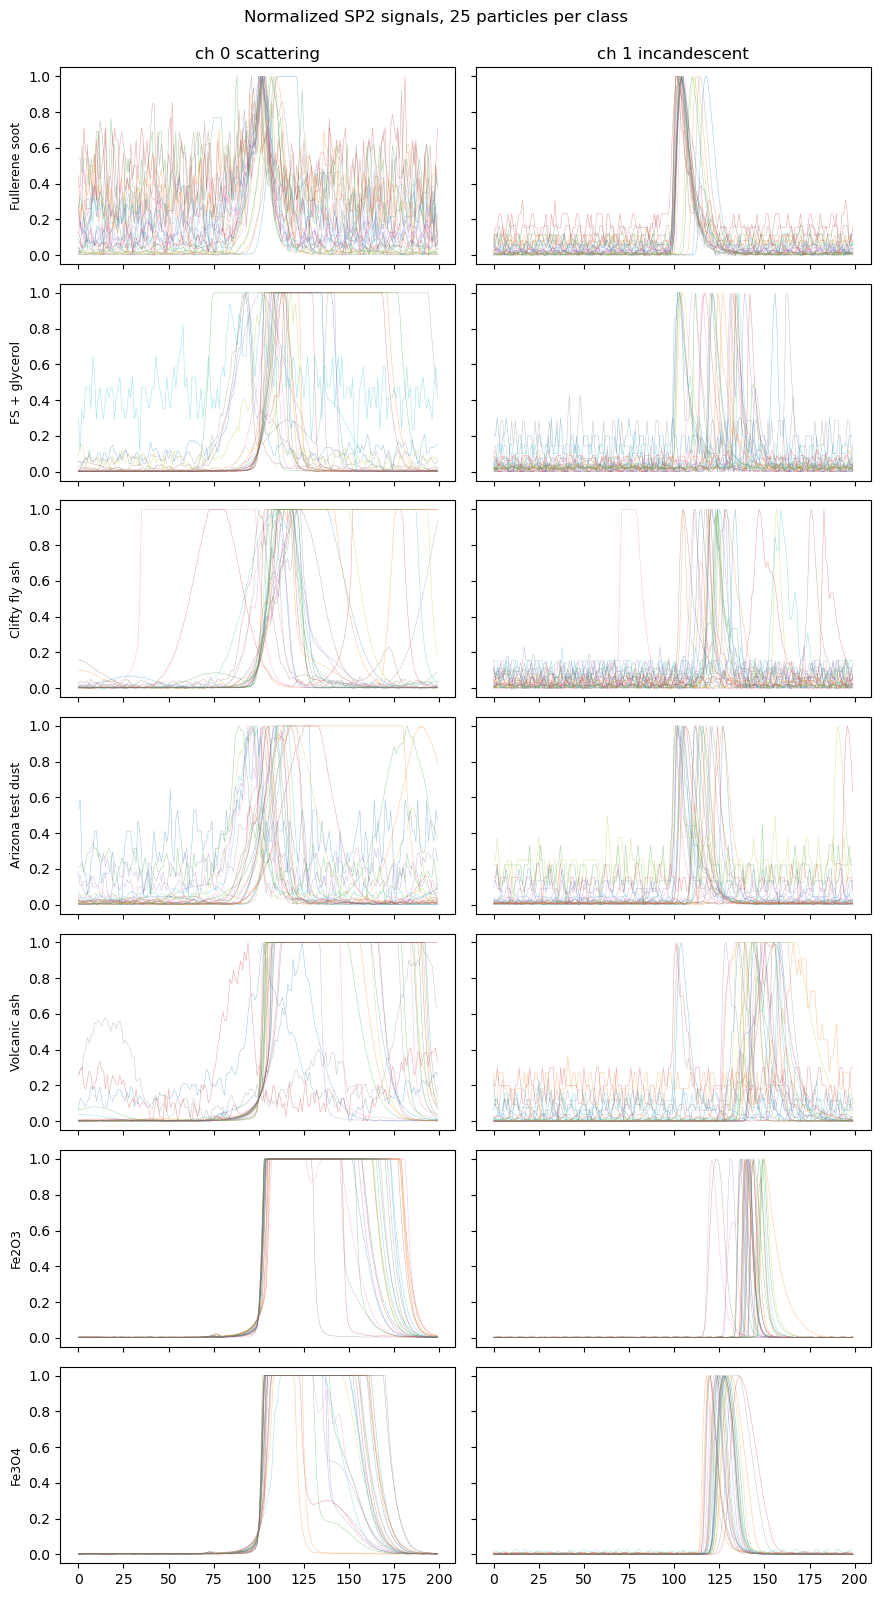

In [6]:
fig, axes = plt.subplots(7, 2, figsize=(9, 16), sharex=True, sharey=True)
for c in range(7):
    for i in np.flatnonzero(y == c)[:25]:
        axes[c, 0].plot(X[i, :, 0], lw=0.4, alpha=0.4)
        axes[c, 1].plot(X[i, :, 1], lw=0.4, alpha=0.4)
    axes[c, 0].set_ylabel(CLASSES[c], fontsize=9)
axes[0, 0].set_title("ch 0 scattering")
axes[0, 1].set_title("ch 1 incandescent")
fig.suptitle("Normalized SP2 signals, 25 particles per class", y=0.995)
plt.tight_layout(); plt.show()

The shapes really do differ. Fullerene soot gives a narrow, symmetric
incandescence peak and almost no scattering signal at all (its scattering trace
is pure detector noise, which the normalization then stretches to fill the
axis). The iron oxides give a broad, flat-topped scattering trace (the detector
is saturated) and a later, wider incandescence peak. The dusts are messy and
heterogeneous, because "Arizona test dust" is not one material but a mixture of
mineral grains.

Those are exactly the features a human analyst would point at. Now let us see
what the models find.

---

# Example 1: a VAE latent space for seven aerosol types

A [variational autoencoder](vaes.ipynb) squeezes each signal through a narrow
bottleneck and reconstructs it from the other side. Nothing in the training
objective mentions the aerosol type: the VAE never sees `y`. If the seven
classes end up in different regions of the bottleneck, that is the model
discovering differences between the different classes of aerosols on its own.

All three examples work on **channel 1, the incandescent trace**, which is the
signal the SP2 records as a particle burns up. The paper trains a separate VAE
on each channel; we keep to one so that the same 200-point input feeds all three
models.

We use a **2-dimensional** latent space, so we can simply plot it. (The paper
found 3 dimensions optimal; you will see below that going from 2 to 3 buys a
little accuracy and costs the ability to make this plot.)

The VAE encoder outputs a mean and a log-variance for each latent coordinate,
and we sample from that Gaussian during training. The loss is the usual sum of a
reconstruction term and a KL term that pulls the posterior towards a standard
normal:

In [7]:
tf.random.set_seed(0)     # seed each example separately, so they stay independent
LATENT_DIM = 2


class Sampling(layers.Layer):
    "Draw z ~ N(mu, sigma^2) using the reparameterisation trick."
    def call(self, inputs):
        mu, logvar = inputs
        return mu + tf.exp(0.5 * logvar) * tf.random.normal(tf.shape(mu))


x_in = keras.Input((T, 1))
h = layers.Flatten()(x_in)
h = layers.Dense(256, activation="relu")(h)
h = layers.Dense(128, activation="relu")(h)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(h)
z_logvar = layers.Dense(LATENT_DIM, name="z_logvar")(h)
encoder = keras.Model(x_in, [z_mean, z_logvar, Sampling()([z_mean, z_logvar])],
                      name="encoder")

z_in = keras.Input((LATENT_DIM,))
g = layers.Dense(128, activation="relu")(z_in)
g = layers.Dense(256, activation="relu")(g)
g = layers.Dense(T, activation="sigmoid")(g)
decoder = keras.Model(z_in, layers.Reshape((T, 1))(g), name="decoder")

encoder.summary()

Model: "encoder"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_1 (InputLayer)        [(None, 200, 1)]             0         []                            


 flatten (Flatten)           (None, 200)                  0         ['input_1[0][0]']             


...

                                                                     'z_logvar[0][0]']            


Total params: 84868 (331.52 KB)


Trainable params: 84868 (331.52 KB)


Non-trainable params: 0 (0.00 Byte)


__________________________________________________________________________________________________


In [8]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder
        self.tracker = keras.metrics.Mean(name="loss")

    def train_step(self, x):
        with tf.GradientTape() as tape:
            mu, logvar, z = self.encoder(x)
            reconstruction = self.decoder(z)
            rec_loss = tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2])
            kl_loss = -0.5 * tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            loss = tf.reduce_mean(rec_loss + kl_loss)
        self.optimizer.apply_gradients(
            zip(tape.gradient(loss, self.trainable_weights), self.trainable_weights))
        self.tracker.update_state(loss)
        return {"loss": self.tracker.result()}


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.legacy.Adam(1e-3))

if not load_if_saved(vae_encoder=encoder, vae_decoder=decoder):
    t0 = time.time()
    history = vae.fit(X1, epochs=60, batch_size=128, verbose=0)
    print(f"trained in {time.time() - t0:.0f} s, "
          f"final loss {history.history['loss'][-1]:.2f}")
    save_weights(vae_encoder=encoder, vae_decoder=decoder)

loaded weights/vae_encoder.h5, weights/vae_decoder.h5 - delete these to train again


First a sanity check: can two numbers really rebuild a 200-point signal?

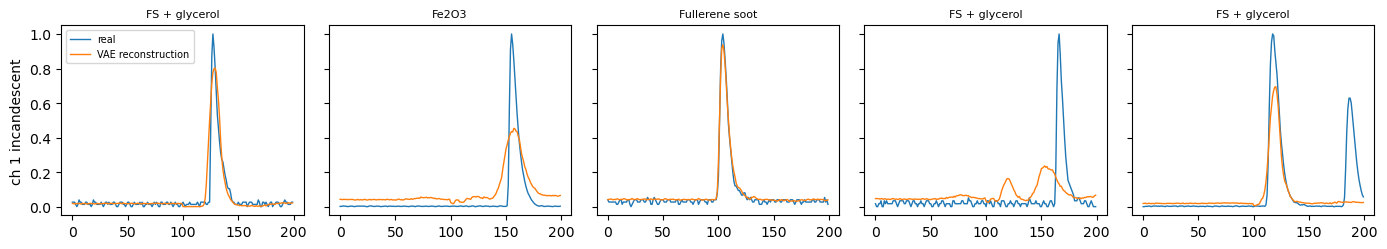

In [9]:
Z = encoder.predict(X1, verbose=0)[0]       # use the posterior mean as "the" code
recon = decoder.predict(Z, verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(14, 2.6), sharex=True, sharey=True)
for ax, i in zip(axes, np.random.default_rng(3).choice(len(X1), 5, replace=False)):
    ax.plot(X1[i, :, 0], lw=1, label="real")
    ax.plot(recon[i, :, 0], lw=1, label="VAE reconstruction")
    ax.set_title(CLASSES[y[i]], fontsize=8)
axes[0].set_ylabel("ch 1 incandescent"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

Two numbers get you a lot, but not everything. The peak lands in the right place
almost every time, and for the narrow-peaked soots the reconstruction is close to
exact. Two failure modes show up clearly. The reconstructed peak is often *too
short*, most visibly for Fe2O3, where a saturated trace comes back at roughly half
height. And anything unusual is dropped: a particle whose peak arrives unusually
late, or which incandesces twice, gets reconstructed as a single peak in the
ordinary place. That is a two-number bottleneck doing exactly what it should,
spending its capacity on what is common across 8096 signals.

The reconstructions are also *smooth*: the high-frequency detector noise in the
real traces is gone, because noise is by definition not compressible.

Now the plot we came for. Color each particle's latent code by its true class:

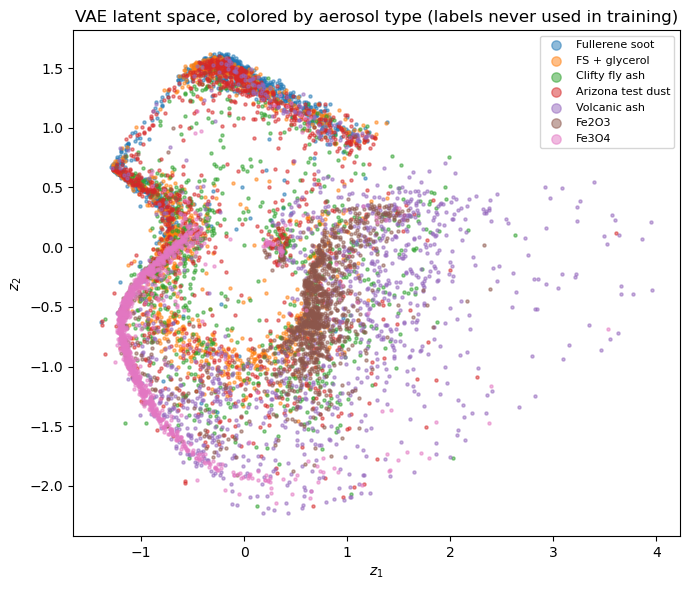

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for c in range(7):
    m = y == c
    ax.scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.5, label=CLASSES[c])
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.legend(markerscale=3, fontsize=8)
ax.set_title("VAE latent space, colored by aerosol type (labels never used in training)")
plt.tight_layout(); plt.show()

Structure, and more of it than the raw traces might lead you to expect. Three
things are worth picking out.

The **two soots pile into one tight cluster**, at the far end of the $z_1$ axis,
with Arizona test dust mixed into the same knot. These are the narrow, symmetric,
early-peaking signals, and the model puts them all in nearly the same place.

The **two iron oxides each get their own filament**, and the two filaments are
distinct from each other: Fe3O4 traces one dense arc and Fe2O3 another, running
in a different direction. This is the pair the paper singles out, so it is worth
noting that an unsupervised model separates them on signal shape alone.

The **dusts and volcanic ash spread out diffusely** across the rest of the map
rather than forming a cluster, which is what heterogeneous material should look
like: "Arizona test dust" is not one substance but a mixture of mineral grains.

(A VAE's latent axes have no fixed sign or ordering, so if you re-run the training
your map may come out rotated or mirrored relative to this one. Only the
*relative* arrangement is meaningful.)

To read the map, decode a grid of latent coordinates and see what signal each
point of the plane corresponds to. This is the VAE equivalent of looking at
principal component loadings:

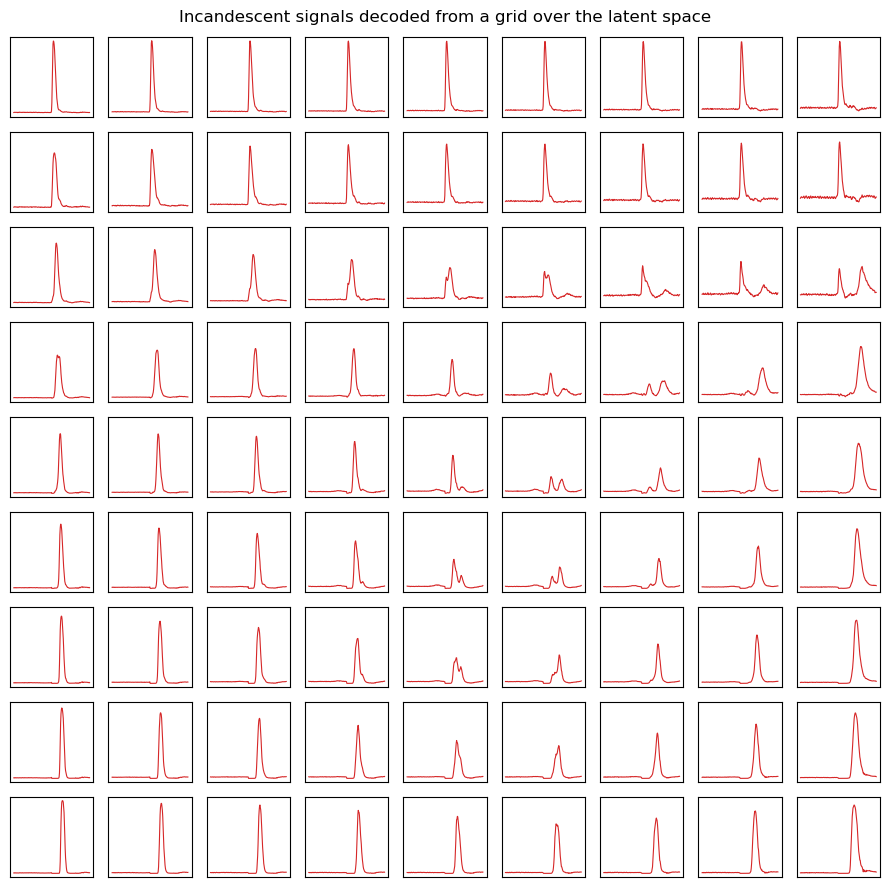

In [11]:
from scipy.stats import norm

d = 9
gx = norm.ppf(np.linspace(0.05, 0.95, d))       # evenly spaced in probability
grid = np.array([[a, b] for b in gx[::-1] for a in gx], dtype="float32")
manifold = decoder.predict(grid, verbose=0)

fig, axes = plt.subplots(d, d, figsize=(9, 9), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    ax.plot(manifold[k, :, 0], lw=0.8, color="tab:red")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Incandescent signals decoded from a grid over the latent space")
plt.tight_layout(); plt.show()

The manifold is smooth and physically interpretable, and this is the real payoff
of a VAE over a plain autoencoder. Moving across the grid, the peak slides later
in the time window. Moving down it, the trace sharpens and the baseline noise
falls away. And there is a pocket in the upper middle where the decoder produces
**double-peaked** signals, the shape a particle makes when it incandesces twice.
Every point of the plane decodes to a plausible SP2 signal, not just the points
where training data happened to land.

Finally, a number instead of an impression. If the latent space really organizes
the classes, a simple nearest-neighbor classifier on the two latent coordinates
should do far better than chance:

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn_latent = cross_val_score(KNeighborsClassifier(15), Z, y, cv=3).mean()
knn_raw = cross_val_score(KNeighborsClassifier(15), X1[:, :, 0], y, cv=3).mean()

print(f"15-NN accuracy on the {LATENT_DIM} latent coordinates : {knn_latent:.3f}")
print(f"15-NN accuracy on all {T} raw numbers            : {knn_raw:.3f}")
print(f"chance                                       : {1/7:.3f}")

15-NN accuracy on the 2 latent coordinates : 0.512
15-NN accuracy on all 200 raw numbers            : 0.578
chance                                       : 0.143


Two coordinates retain most of what the full 200-point trace carries, at a
100-fold compression. Neither number is close to 1.0, and it is worth being
clear about why.

Part of it is the science: several of these aerosols genuinely produce
overlapping SP2 signatures once you take the peak height away, and quantifying
that overlap is part of the paper's contribution. But part of it is simply that
we have handicapped the models, deliberately, to keep this tutorial runnable in a
class session. **We train on 8,096 signals** out of the 42,960 incandescing
particles in the test split alone, and the full data set also has train and
validation splits we never download. And **we use one of the instrument's four
channels**, throwing away the scattering trace, the red incandescent channel, and
the position-sensitive detector, along with the peak heights we normalized out.
None of these models is being shown anything close to the information the SP2
actually records. Expect every number on this page to improve if you give them
more.

> **Try it:** set `LATENT_DIM = 3` and re-run the three cells above. The
> classifier improves (the paper found 3 dimensions optimal) but you lose the
> plot. How much accuracy is a picture worth?

---

# Example 2: a GAN as an anomaly detector for fullerene soot

Fullerene soot is the standard laboratory proxy for atmospheric black carbon,
and it is what an SP2 is normally calibrated against. Suppose we deploy an
instrument in the field: we would like it to tell us when a particle is *not*
behaving like the soot we calibrated on: perhaps it is dust, or an iron oxide,
or something we have never characterized.

That is a **one-class** problem. We cannot train a classifier for "everything
that isn't soot", because we do not have examples of everything. But we can
learn what soot looks like and measure how badly a new signal fits.

A [GAN](gansdiffusion.ipynb) gives us exactly that. Train the generator on
fullerene soot alone and it learns to produce soot signals and nothing else.
Then for a new signal, search the latent space for the code whose generated
signal comes closest. If even the best match is poor, the signal is anomalous.
This is the **AnoGAN** recipe
([Schlegl et al. 2017](https://arxiv.org/abs/1703.05921)), originally developed
for finding disease markers in retinal scans.

In [13]:
tf.random.set_seed(0)
NOISE_DIM = 16
Xg = X1                                 # the same incandescent signals as the VAE

rng2 = np.random.default_rng(1)
soot = np.flatnonzero(y == 0)
rng2.shuffle(soot)

gan_train = Xg[soot[:1000]]             # the GAN sees ONLY fullerene soot
test_idx = np.concatenate([soot[1000:1200]] +
    [rng2.choice(np.flatnonzero(y == c), 200, replace=False) for c in range(1, 7)])
X_test, y_test = Xg[test_idx], y[test_idx]

print("GAN training set (fullerene soot only):", gan_train.shape)
print("held-out test set (200 per class)     :", X_test.shape)

GAN training set (fullerene soot only): (1000, 200, 1)
held-out test set (200 per class)     : (1400, 200, 1)


In [14]:
generator = keras.Sequential([
    keras.Input((NOISE_DIM,)),
    layers.Dense(25 * 64), layers.LeakyReLU(0.2), layers.Reshape((25, 64)),
    layers.Conv1DTranspose(64, 5, strides=2, padding="same"), layers.LeakyReLU(0.2),
    layers.Conv1DTranspose(32, 5, strides=2, padding="same"), layers.LeakyReLU(0.2),
    layers.Conv1DTranspose(32, 5, strides=2, padding="same"), layers.LeakyReLU(0.2),
    layers.Conv1D(1, 5, padding="same", activation="sigmoid"),
], name="generator")

discriminator = keras.Sequential([
    keras.Input((T, 1)),
    layers.Conv1D(32, 5, strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Conv1D(64, 5, strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Conv1D(64, 5, strides=2, padding="same"), layers.LeakyReLU(0.2),
    layers.Flatten(), layers.Dense(1),
], name="discriminator")

generator.summary()

Model: "generator"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense_5 (Dense)             (None, 1600)              27200     


 leaky_re_lu (LeakyReLU)     (None, 1600)              0         


...

 conv1d (Conv1D)             (None, 200, 1)            161       


Total params: 63329 (247.38 KB)


Trainable params: 63329 (247.38 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


The training loop is the two-player game from the notes, written out explicitly
because Keras has no built-in "fit a GAN": one gradient step for the
discriminator (real → 1, fake → 0), then one for the generator (fool the
discriminator into saying 1).

In [15]:
bce = keras.losses.BinaryCrossentropy(from_logits=True)
opt_g = keras.optimizers.legacy.Adam(2e-4, beta_1=0.5)
opt_d = keras.optimizers.legacy.Adam(2e-4, beta_1=0.5)


@tf.function
def gan_step(real):
    n = tf.shape(real)[0]

    with tf.GradientTape() as tape:                       # discriminator
        fake = generator(tf.random.normal((n, NOISE_DIM)), training=True)
        d_loss = (bce(tf.ones((n, 1)), discriminator(real, training=True))
                  + bce(tf.zeros((n, 1)), discriminator(fake, training=True)))
    opt_d.apply_gradients(zip(tape.gradient(d_loss, discriminator.trainable_weights),
                              discriminator.trainable_weights))

    with tf.GradientTape() as tape:                       # generator
        fake = generator(tf.random.normal((n, NOISE_DIM)), training=True)
        g_loss = bce(tf.ones((n, 1)), discriminator(fake, training=True))
    opt_g.apply_gradients(zip(tape.gradient(g_loss, generator.trainable_weights),
                              generator.trainable_weights))
    return d_loss, g_loss


if not load_if_saved(gan_generator=generator, gan_discriminator=discriminator):
    t0 = time.time()
    ds = tf.data.Dataset.from_tensor_slices(gan_train).shuffle(1000).batch(64)
    history = []
    for epoch in range(60):
        epoch_losses = []
        for batch in ds:
            d_loss, g_loss = gan_step(batch)
            epoch_losses.append([float(d_loss), float(g_loss)])
        history.append(np.mean(epoch_losses, axis=0))       # mean over the epoch
        if epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  d_loss {history[-1][0]:.3f}  "
                  f"g_loss {history[-1][1]:.3f}")
    print(f"trained in {time.time() - t0:.0f} s")
    save_weights(gan_generator=generator, gan_discriminator=discriminator)
    np.save(f"{WEIGHTS}/gan_history.npy", np.array(history))

gan_history = np.load(f"{WEIGHTS}/gan_history.npy")

  epoch   0  d_loss 1.296  g_loss 0.814


  epoch  20  d_loss 1.264  g_loss 0.803


  epoch  40  d_loss 1.352  g_loss 0.716


trained in 25 s
saved weights/gan_generator.h5, weights/gan_discriminator.h5


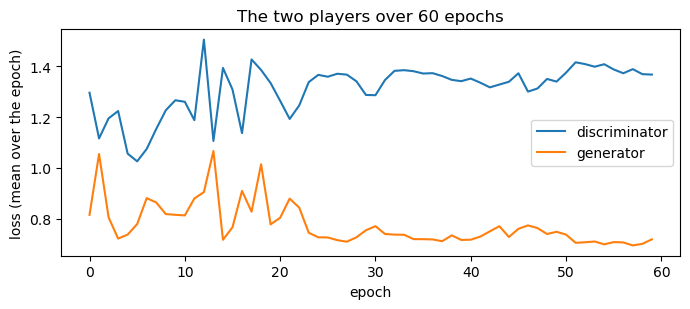

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(gan_history[:, 0], label="discriminator")
ax.plot(gan_history[:, 1], label="generator")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (mean over the epoch)")
ax.set_title("The two players over 60 epochs")
ax.legend()
plt.tight_layout(); plt.show()

Read that plot the way you would *not* read a supervised loss curve. Neither line
falls towards zero. Both bounce around for the first twenty epochs or so, then
settle onto roughly flat plateaus, the discriminator near 1.35 and the generator
near 0.72, and stay there. That is what success looks like here: the two networks
are chasing each other, and a GAN that is training well looks like a stalemate. A
discriminator loss collapsing towards zero would mean the generator had *stopped*
fooling it. Since the loss cannot tell you whether the samples are any good, judge
it by the samples.

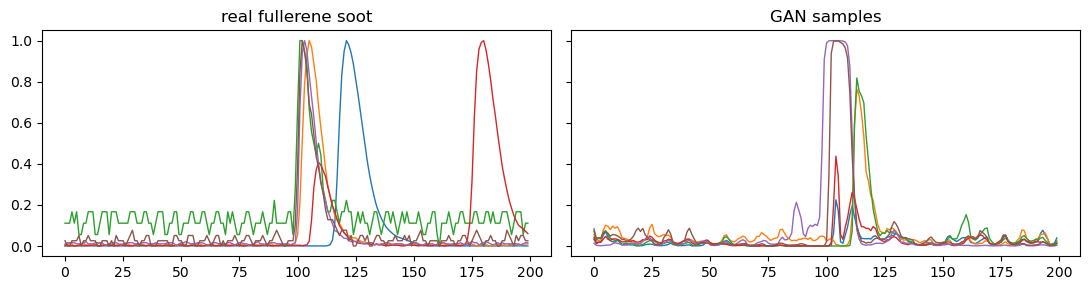

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for i in range(6):
    axes[0].plot(gan_train[rng2.integers(len(gan_train)), :, 0], lw=1)
    axes[1].plot(generator(tf.random.normal((1, NOISE_DIM)))[0, :, 0], lw=1)
axes[0].set_title("real fullerene soot")
axes[1].set_title("GAN samples")
plt.tight_layout(); plt.show()

The generator has learned the narrow peak, its typical position, and even the
level of the detector noise floor around it.

### Scoring a new signal

The generator maps a latent code to a signal, but there is no inverse. AnoGAN's
answer is to *search*: hold the generator fixed and run gradient descent on the
latent code $z$ until $G(z)$ matches the query signal as well as it can. The
final mismatch is the anomaly score. We use the standard combination of a direct
residual and a "feature" residual measured in the discriminator's last hidden
layer, which compares signals the way the discriminator learned to.

All 1400 test signals are optimised at once as one batch, so this takes seconds
rather than minutes.

In [18]:
features = keras.Model(discriminator.input, discriminator.layers[-2].output)


def anomaly_score(x, steps=200, lr=0.05):
    "Search for the latent code whose generated signal best matches x."
    x = tf.constant(x, tf.float32)
    z = tf.Variable(tf.random.normal((x.shape[0], NOISE_DIM)))
    opt = keras.optimizers.legacy.Adam(lr)
    fx = features(x)
    for _ in range(steps):
        with tf.GradientTape() as tape:
            fake = generator(z)
            score = (tf.reduce_mean(tf.abs(x - fake), axis=[1, 2])
                     + 0.1 * tf.reduce_mean(tf.abs(fx - features(fake)), axis=1))
            total = tf.reduce_sum(score)
        opt.apply_gradients([(tape.gradient(total, z), z)])
    return score.numpy(), generator(z).numpy()


t0 = time.time()
score, best_fit = anomaly_score(X_test)
print(f"scored {len(X_test)} signals in {time.time() - t0:.0f} s")

scored 1400 signals in 36 s


In [19]:
from sklearn.metrics import roc_auc_score, roc_curve

is_anomaly = (y_test != 0).astype(int)
auc = roc_auc_score(is_anomaly, score)
print(f"AUC, fullerene soot vs everything else: {auc:.3f}\n")
for c in np.argsort([np.median(score[y_test == c]) for c in range(7)]):
    print(f"  {CLASSES[c]:20s} median score {np.median(score[y_test == c]):.4f}")

AUC, fullerene soot vs everything else: 0.793

  Fullerene soot       median score 0.0210
  Arizona test dust    median score 0.0322
  Fe2O3                median score 0.0345
  FS + glycerol        median score 0.0372
  Clifty fly ash       median score 0.0487
  Fe3O4                median score 0.0520
  Volcanic ash         median score 0.0576


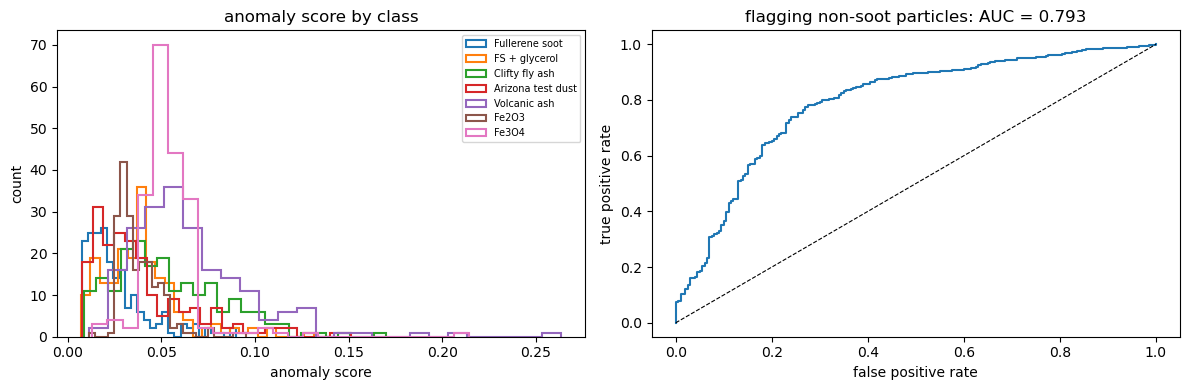

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for c in range(7):
    axes[0].hist(score[y_test == c], bins=25, histtype="step", lw=1.5, label=CLASSES[c])
axes[0].set_xlabel("anomaly score"); axes[0].set_ylabel("count")
axes[0].legend(fontsize=7); axes[0].set_title("anomaly score by class")

fpr, tpr, _ = roc_curve(is_anomaly, score)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"flagging non-soot particles: AUC = {auc:.3f}")
plt.tight_layout(); plt.show()

Fullerene soot has the lowest median score of the seven, which is what a
one-class detector is supposed to deliver, but look at the overlap. Plenty of
Arizona test dust and glycerol-coated soot particles score as low as real soot
does. That overlap is the difference between an AUC near 0.8 and an AUC near
1.0, and it is a genuine property of the data rather than a shortcoming of the
training run: some of these particles produce incandescence traces that are
essentially indistinguishable from soot once the peak height is normalized away.

Note also that the ranking of the six anomalous classes carries no physical
meaning. The score measures distance from soot *in signal space*, and a class
does not have to be chemically far from soot to land far away there.

Looking at what the generator actually produced for each query makes the failure
mode concrete:

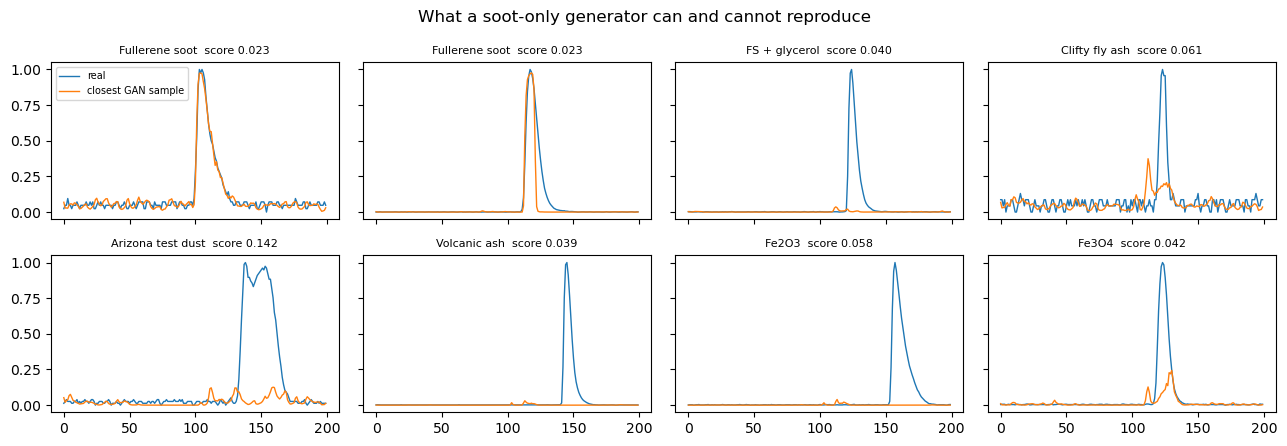

In [21]:
picks = [(0, 0), (0, 1), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0)]
fig, axes = plt.subplots(2, 4, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, (c, k) in zip(axes.ravel(), picks):
    i = np.flatnonzero(y_test == c)[k]
    ax.plot(X_test[i, :, 0], lw=1, label="real")
    ax.plot(best_fit[i, :, 0], lw=1, label="closest GAN sample")
    ax.set_title(f"{CLASSES[y_test[i]]}  score {score[i]:.3f}", fontsize=8)
axes[0, 0].legend(fontsize=7)
fig.suptitle("What a soot-only generator can and cannot reproduce")
plt.tight_layout(); plt.show()

For fullerene soot the generator finds a near-perfect match, noise floor and
all. For the other classes it cannot: the peak is in the wrong place, or too
wide, and in the worst cases the search gives up and returns something nearly
flat. That residual *is* the anomaly score.

> **Try it:** train the same GAN on Fe2O3 instead (`y == 5`) and score the rest.
> Which classes now look normal? Does fullerene soot become the anomaly?

---

# Example 3: a conditional diffusion model for all seven classes

The VAE and the GAN both learned one distribution. A **conditional** generative
model learns a *family* of distributions indexed by a label.

"Conditional" in machine learning means the model takes an extra input alongside
its usual one and its output depends on that input. Here the extra input is the
aerosol class, so instead of learning "what does an SP2 signal look like?" the
model learns "what does an SP2 signal *of class c* look like?" The label is not
something the model predicts, the way a classifier would; it is something we hand
it, and it steers what comes out. That is what lets us ask for "an Fe2O3 signal"
or "a fullerene soot signal" on demand. That is what makes
generative models useful for augmenting training sets, for simulating
instruments, and for testing analysis pipelines against synthetic data with
known ground truth.

We build a [denoising diffusion model](gansdiffusion.ipynb) on the incandescent
channel. The recipe:

- **Forward process:** add Gaussian noise to a real signal in $T = 200$ small
  steps until nothing is left but noise. This needs no training, since it is a
  fixed schedule.
- **Reverse process:** train a network to predict, given a noisy signal, the
  time step, *and the class label*, what noise was added. Generation starts from
  pure noise and subtracts the predicted noise 200 times.

Diffusion models are far more stable to train than GANs, because the loss is an
ordinary mean-squared error with no adversarial game. That is the main reason
they took over image generation.

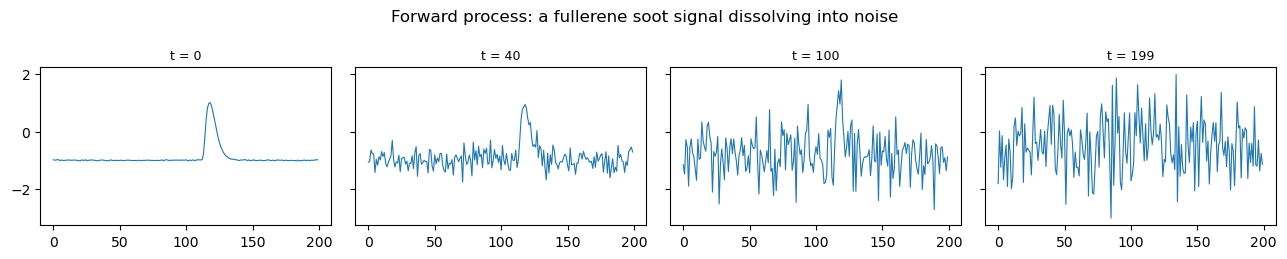

In [22]:
NUM_STEPS = 200
NULL_LABEL = 7                       # an eighth "no class specified" token, used below

betas = np.linspace(1e-4, 0.02, NUM_STEPS).astype("float32")   # noise added per step
alpha_bar = np.cumprod(1 - betas).astype("float32")            # signal surviving to step t
alpha_bar_tf = tf.constant(alpha_bar)

X_diff = (2 * X1 - 1).astype("float32")                        # rescale to [-1, 1]

fig, axes = plt.subplots(1, 4, figsize=(13, 2.6), sharey=True)
i = np.flatnonzero(y == 0)[0]
for ax, t in zip(axes, [0, 40, 100, 199]):
    noisy = (np.sqrt(alpha_bar[t]) * X_diff[i, :, 0]
             + np.sqrt(1 - alpha_bar[t]) * np.random.randn(T))
    ax.plot(noisy, lw=0.8); ax.set_title(f"t = {t}", fontsize=9)
fig.suptitle("Forward process: a fullerene soot signal dissolving into noise")
plt.tight_layout(); plt.show()

The denoiser is a small 1-D U-Net: three resolutions down, two back up, with
skip connections. Two extra inputs are mixed into every block as a learned
embedding: the time step (encoded with sinusoids, as in a transformer) and the
class label. A constant position ramp is concatenated to the input as well;
without it the convolutions are nearly translation-invariant and the model puts
the peak in the wrong place.

In [23]:
def build_denoiser():
    x_in = keras.Input((T, 1))
    t_in = keras.Input((), dtype="int32")
    y_in = keras.Input((), dtype="int32")

    freqs = tf.exp(tf.linspace(0.0, -4.0, 32) * tf.math.log(10.0))
    ang = tf.cast(t_in, tf.float32)[:, None] * freqs[None, :]
    emb = layers.Dense(64, activation="swish")(tf.concat([tf.sin(ang), tf.cos(ang)], -1))
    emb = emb + layers.Embedding(8, 64)(y_in)          # 7 classes + the null token
    emb = layers.Dense(64, activation="swish")(emb)

    def block(h, ch):
        h = layers.Conv1D(ch, 5, padding="same", activation="swish")(h)
        h = h + layers.Dense(ch)(emb)[:, None, :]      # inject time + class
        return layers.Conv1D(ch, 5, padding="same", activation="swish")(h)

    pos = tf.linspace(-1.0, 1.0, T)[None, :, None] * tf.ones_like(x_in[:, :, :1])
    h1 = block(layers.Concatenate()([x_in, pos]), 32)          # 200 points
    h2 = block(layers.AveragePooling1D(2)(h1), 64)             # 100
    h3 = block(layers.AveragePooling1D(2)(h2), 128)            #  50
    u2 = block(layers.Concatenate()([layers.UpSampling1D(2)(h3), h2]), 64)
    u1 = block(layers.Concatenate()([layers.UpSampling1D(2)(u2), h1]), 32)
    return keras.Model([x_in, t_in, y_in], layers.Conv1D(1, 5, padding="same")(u1))


tf.random.set_seed(0)
denoiser = build_denoiser()
print("denoiser parameters:", denoiser.count_params())

denoiser parameters: 291873


One trick in the training step: **10 % of the time we replace the real label
with the null token**, so the same network learns both the class-conditional and
the unconditional denoiser. That is what makes *classifier-free guidance*
possible at sampling time, and we will measure below how much it matters.

In [24]:
EPOCHS = 80
steps_total = EPOCHS * int(np.ceil(len(X_diff) / 128))
opt_dn = keras.optimizers.legacy.Adam(
    keras.optimizers.schedules.CosineDecay(1e-3, steps_total, alpha=0.05))


@tf.function
def diffusion_step(x0, label):
    n = tf.shape(x0)[0]
    label = tf.where(tf.random.uniform((n,)) < 0.1, NULL_LABEL, label)   # label dropout
    t = tf.random.uniform((n,), 0, NUM_STEPS, dtype=tf.int32)
    a = tf.gather(alpha_bar_tf, t)[:, None, None]
    eps = tf.random.normal(tf.shape(x0))
    x_t = tf.sqrt(a) * x0 + tf.sqrt(1 - a) * eps          # jump straight to step t
    with tf.GradientTape() as tape:
        loss = tf.reduce_mean(tf.square(eps - denoiser([x_t, t, label], training=True)))
    opt_dn.apply_gradients(zip(tape.gradient(loss, denoiser.trainable_weights),
                               denoiser.trainable_weights))
    return loss


if not load_if_saved(diffusion_denoiser=denoiser):
    t0 = time.time()
    ds = tf.data.Dataset.from_tensor_slices(
        (X_diff, y.astype("int32"))).shuffle(8000).batch(128)
    running = None
    for epoch in range(EPOCHS):
        for xb, yb in ds:
            l = float(diffusion_step(xb, yb))
            running = l if running is None else 0.99 * running + 0.01 * l
        if epoch % 10 == 0:
            print(f"  epoch {epoch:3d}  loss {running:.4f}  ({time.time() - t0:.0f} s)")
    print(f"trained in {time.time() - t0:.0f} s")
    save_weights(diffusion_denoiser=denoiser)

loaded weights/diffusion_denoiser.h5 - delete these to train again


### Sampling

Start from pure noise and walk the schedule backwards. With **classifier-free
guidance** we run the denoiser twice at each step, once with the class label and
once with the null token, and extrapolate away from the unconditional
prediction:

$$\hat\epsilon = (1 + w)\,\epsilon_\theta(x_t, t, c) - w\,\epsilon_\theta(x_t, t, \varnothing)$$

The guidance weight $w$ trades diversity for class fidelity. $w = 0$ is ordinary
conditional sampling. We generate 20 signals per class at three guidance
weights so we can compare them later; the figures below use $w = 3$.

In [25]:
def sample(labels, guidance=3.0, snapshots=()):
    n = len(labels)
    labels = tf.constant(np.asarray(labels, "int32"))
    null = tf.fill((n,), NULL_LABEL)
    x = tf.random.normal((n, T, 1))
    saved = {}
    for i in range(NUM_STEPS - 1, -1, -1):
        t_i = tf.fill((n,), i)
        eps = denoiser([x, t_i, labels], training=False)
        if guidance:
            eps = ((1 + guidance) * eps
                   - guidance * denoiser([x, t_i, null], training=False))
        x = (x - betas[i] / np.sqrt(1 - alpha_bar[i]) * eps) / np.sqrt(1 - betas[i])
        if i > 0:
            x = x + np.sqrt(betas[i]) * tf.random.normal(tf.shape(x))
        if i in snapshots:
            saved[i] = np.clip((x.numpy() + 1) / 2, 0, 1)
    return np.clip((x.numpy() + 1) / 2, 0, 1), saved


labels = np.repeat(np.arange(7), 20)      # 20 signals of each class

t0 = time.time()
samples = {}
for w in [0.0, 1.0, 3.0]:
    samples[w], snaps = sample(labels, guidance=w, snapshots=(150, 100, 50))
fake = samples[3.0]
print(f"generated {len(labels)} signals at each of 3 guidance weights "
      f"in {time.time() - t0:.0f} s")

generated 140 signals at each of 3 guidance weights in 73 s


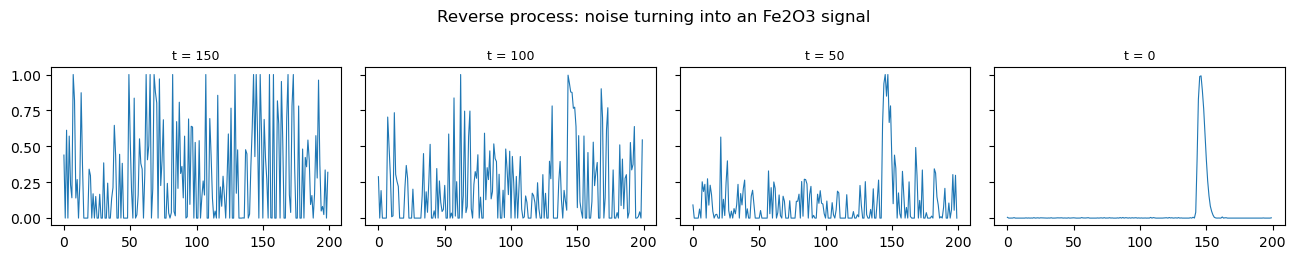

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(13, 2.6), sharey=True)
i = np.flatnonzero(labels == 5)[0]
for ax, t in zip(axes, [150, 100, 50]):
    ax.plot(snaps[t][i, :, 0], lw=0.8); ax.set_title(f"t = {t}", fontsize=9)
axes[3].plot(fake[i, :, 0], lw=0.8); axes[3].set_title("t = 0", fontsize=9)
fig.suptitle("Reverse process: noise turning into an Fe2O3 signal")
plt.tight_layout(); plt.show()

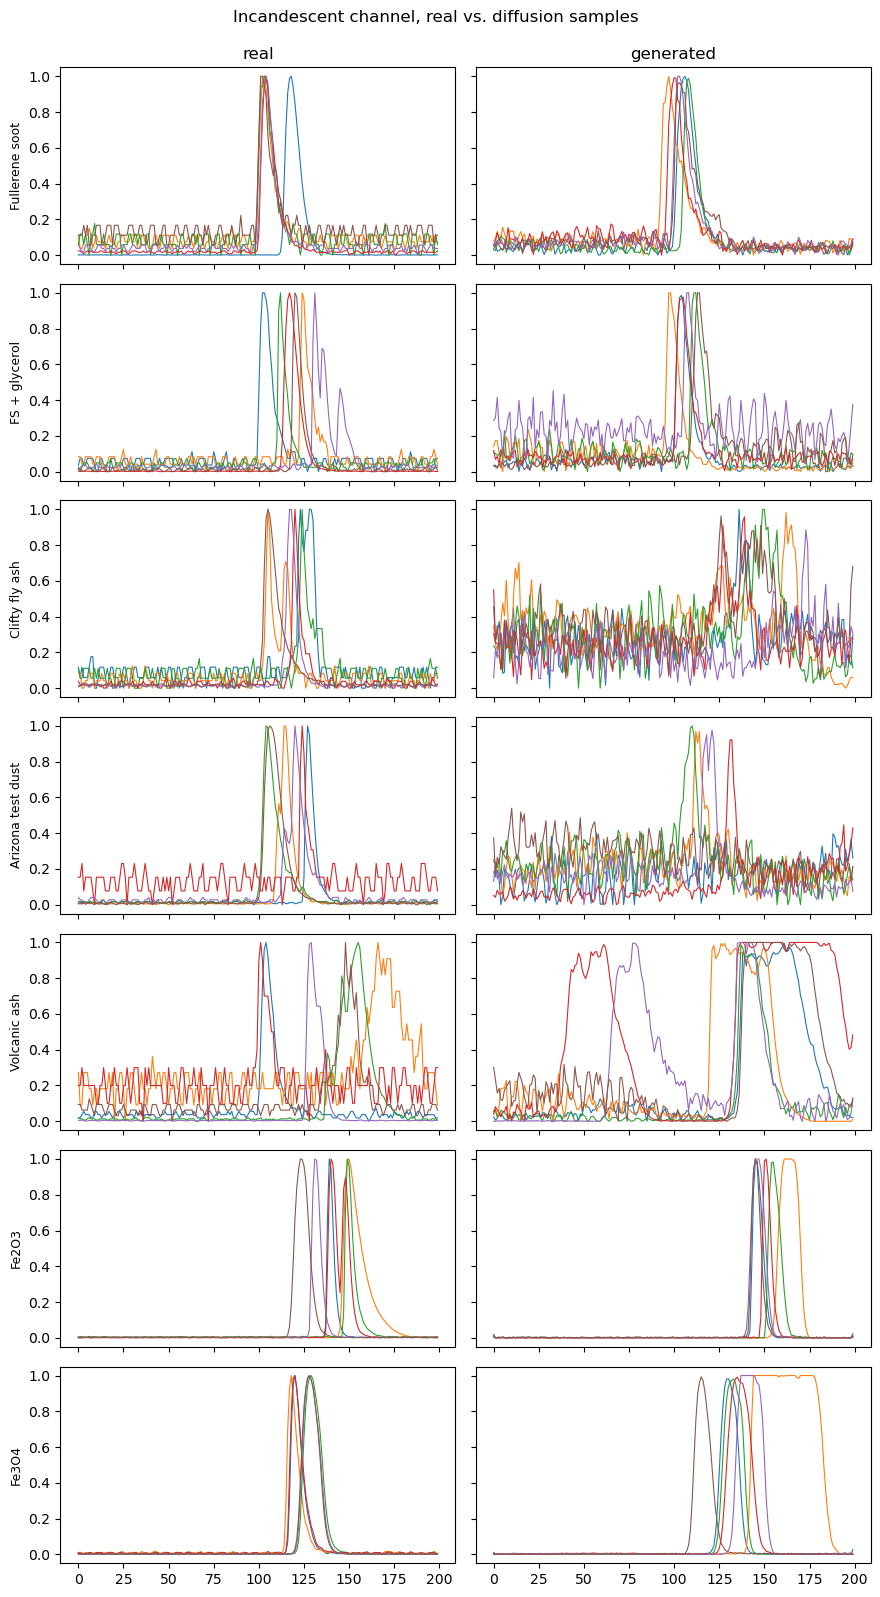

In [27]:
fig, axes = plt.subplots(7, 2, figsize=(9, 16), sharex=True, sharey=True)
for c in range(7):
    for i in np.flatnonzero(y == c)[:6]:
        axes[c, 0].plot(X1[i, :, 0], lw=0.8)
    for i in np.flatnonzero(labels == c)[:6]:
        axes[c, 1].plot(fake[i, :, 0], lw=0.8)
    axes[c, 0].set_ylabel(CLASSES[c], fontsize=9)
axes[0, 0].set_title("real"); axes[0, 1].set_title("generated")
fig.suptitle("Incandescent channel, real vs. diffusion samples", y=0.995)
plt.tight_layout(); plt.show()

### Did it actually condition on the class?

"Looks plausible" is not a result. Two checks.

First, a reference classifier: fit a nearest-neighbor classifier on the *real*
incandescent signals, then ask it to label the generated ones. Its own
cross-validated accuracy on real data is the natural yardstick.

In [28]:
reference = KNeighborsClassifier(15).fit(X1[:, :, 0], y)
ceiling = cross_val_score(KNeighborsClassifier(15), X1[:, :, 0], y, cv=3).mean()

pred = reference.predict(fake[:, :, 0])
print(f"reference classifier on real signals : {ceiling:.3f}  (chance {1/7:.3f})")
print(f"generated signals given their target : {(pred == labels).mean():.3f}\n")
for c in range(7):
    m = labels == c
    print(f"  asked for {CLASSES[c]:20s} got it {(pred[m] == c).mean():.2f} of the time;"
          f"  most common label: {CLASSES[np.bincount(pred[m], minlength=7).argmax()]}")

reference classifier on real signals : 0.578  (chance 0.143)
generated signals given their target : 0.593

  asked for Fullerene soot       got it 0.75 of the time;  most common label: Fullerene soot
  asked for FS + glycerol        got it 0.35 of the time;  most common label: Fullerene soot
  asked for Clifty fly ash       got it 0.75 of the time;  most common label: Clifty fly ash
  asked for Arizona test dust    got it 0.30 of the time;  most common label: Clifty fly ash
  asked for Volcanic ash         got it 0.70 of the time;  most common label: Volcanic ash
  asked for Fe2O3                got it 0.85 of the time;  most common label: Fe2O3
  asked for Fe3O4                got it 0.45 of the time;  most common label: Fe3O4


The classifier assigns the generated signals to the class they were asked for
about as often as it gets *real* signals right. The conditioning is doing real
work, and this is the number the extra training epochs bought: at half the
training length it sat nearer 0.40.

Resist reading that as "the generated signals are indistinguishable from real
ones". It is partly a side effect of the guidance, which pushes samples towards
the most typical example of each class, and a prototype is easier to classify
than a real particle. What the number does establish is that the label input is
genuinely controlling what comes out.

Second, compare summary statistics of the signal shape, the features a
conventional SP2 analysis would extract, class by class:

In [29]:
real_pos, gen_pos = [], []
print(f"{'':22s}{'peak position':>18s}{'peak width':>16s}")
print(f"{'':22s}{'real':>9s}{'gen':>9s}{'real':>8s}{'gen':>8s}")
for c in range(7):
    r, g = X1[y == c, :, 0], fake[labels == c, :, 0]
    real_pos.append(np.median(r.argmax(1)))
    gen_pos.append(np.median(g.argmax(1)))
    print(f"  {CLASSES[c]:20s}{real_pos[-1]:9.0f}{gen_pos[-1]:9.0f}"
          f"{np.median((r > 0.5).sum(1)):8.0f}{np.median((g > 0.5).sum(1)):8.0f}")
print(f"\ncorrelation of the 7 median peak positions: "
      f"{np.corrcoef(real_pos, gen_pos)[0, 1]:.2f}")

                           peak position      peak width
                           real      gen    real     gen
  Fullerene soot            104      102       8      10
  FS + glycerol             119      106       7       8
  Clifty fly ash            125      141       7      26
  Arizona test dust         112      105       7       8
  Volcanic ash              138      138      10      36
  Fe2O3                     142      150       6       6
  Fe3O4                     125      128       9      14

correlation of the 7 median peak positions: 0.90


The generated peak positions track the real ones across classes: the model has
learned, from the label alone, that an Fe2O3 particle incandesces later in the
laser beam than a fullerene soot particle does.

The peak widths are less faithful: the generated peaks come out wider than the
real ones for every class. That is the usual signature of a diffusion model
trained for a few minutes rather than a few hours. It learns *where* the peak
goes before it learns how sharp it is.

Read the per-class table with care, for two reasons. Twenty signals per class is
a small sample, so those numbers move around between runs. And there is a
systematic quirk: the classes that barely incandesce (Clifty fly ash, Arizona
test dust) have genuinely noise-dominated real traces, so *any* generated signal
that comes out noisy tends to get labelled as one of them, whether or not that
is what we asked for. Look at the figure and the table together: the figure is
where you can see that the model reproduces Fe2O3 and Fe3O4 cleanly and the
weakly-incandescing classes poorly.

Finally, the guidance ablation, on the three sets of samples we generated above:

In [30]:
for w, f in samples.items():
    acc = (reference.predict(f[:, :, 0]) == labels).mean()
    print(f"guidance w = {w}:  class accuracy {acc:.3f}")

guidance w = 0.0:  class accuracy 0.357
guidance w = 1.0:  class accuracy 0.386
guidance w = 3.0:  class accuracy 0.593


Guidance buys real class fidelity, and it costs only a second network evaluation
per sampling step. It is not free in general, since pushed far enough it
collapses the diversity of the samples, so that every "Fe2O3" starts to look
like the same Fe2O3, but at these settings the trade is clearly worth making.

Treat these numbers as a trend rather than as precise measurements: each is based
on 140 generated signals, so there is several percent of scatter between runs.
The gap between no guidance and $w = 3$ survives that scatter; the intermediate
point does not always sit neatly between the two.

One caveat worth stating plainly, because it is easy to hide. This is a small
model trained for a few minutes, and **how well it works varies between training
runs**. Across seven runs we measured the peak-position correlation between
0.82 and 0.99 most of the time, but one run came out near zero: the conditioning
simply failed to take, while the training loss looked completely normal. The
loss will not warn you, so the correlation printed above is the check. If yours
comes out low, delete `weights/diffusion_denoiser.h5` and train again. (Halving
the learning rate makes this *worse*, not better; doubling the epochs from 40 to
80 is what bought the class accuracy you see here.)

> **Try it:** push the guidance to `w = 10` and look at the samples. Can you see
> the diversity collapse in the figure before you see it in the number?

---

# Wrapping up

Three architectures, one instrument, three different jobs:

| model | what it learned | what we used it for |
|---|---|---|
| VAE | a smooth 2-D coordinate system for signal shape | visualizing and quantifying how separable the seven aerosols are |
| GAN | the distribution of fullerene soot alone | flagging particles that do not behave like the calibration material |
| conditional diffusion | one distribution per class | generating labelled synthetic signals on demand |

Some things worth carrying away:

- **None of the three ever saw a label during training, except the diffusion
  model, and it used the label only as a conditioning input, never as a target
  to predict.** These are generative, not discriminative, models.
- **Preprocessing decided most of the outcome.** Normalizing away the peak
  height was a deliberate choice to isolate signal *shape*; it also threw away
  the single most discriminating feature in the data set. Every number above
  would be higher if we had kept it.
- **These models are underfed, on purpose.** They see 8,096 signals and one of
  four instrument channels, because the whole tutorial has to run in a class
  session on a laptop. That, as much as anything intrinsic to the aerosols, is
  why none of the scores is spectacular. Treat the numbers here as a floor, not
  as what the method can do.
- **Verify generative models with numbers, not with pictures.** Plausible-looking
  samples are easy; samples that a classifier trained on real data agrees with
  are not.

### Exercises

1. Add channel 2 (the red incandescent detector) to the VAE input and compute
   the **color ratio** (peak ch1 divided by peak ch2), which is the classical
   SP2 proxy for particle temperature. Is the color ratio recoverable from the
   latent coordinates?
2. The two iron oxides, Fe2O3 and Fe3O4, are the pair the paper found most
   interesting. Train a VAE on those two classes alone with a 2-D latent space.
   Do they separate?
3. Use the trained diffusion model as a data-augmentation engine: generate 500
   signals per class, train a supervised classifier on the synthetic data only,
   and test it on real data. How close does it get to a classifier trained on
   real data?
4. The GAN in Example 2 was trained on 1000 signals. Retrain it on 100 and on
   5000 and plot the anomaly-detection AUC against training-set size.
5. Lamb (2019) classified these same aerosols with a **random forest** on
   hand-built features (peak height, color ratio, peak width). Train one on the
   scalar features you can compute from `X` and `peak`, and compare its accuracy
   with the 0.58 the VAE latent space gave us. Where does the supervised model
   win, and what does it need that the VAE did not?

Note that all three trained models are cached in `weights/`. Delete a file there
to retrain that model from scratch; leave them alone and the notebook re-runs in
under a minute.

### References

- Lamb, K. D. (2019), *Classification of iron oxide aerosols by a single particle
  soot photometer using supervised machine learning*, Atmospheric Measurement
  Techniques 12, 3885–3906, <https://amt.copernicus.org/articles/12/3885/2019/>.
  The paper that introduced this laboratory data set, and classified it with a
  random forest.
- Doshi, A. and Lamb, K. D. (2025), *Unsupervised classification of absorbing
  aerosols with the SP2 via a variational autoencoder*, Atmospheric Measurement
  Techniques 18, 7767, <https://amt.copernicus.org/articles/18/7767/2025/amt-18-7767-2025.html>.
  Code: <https://github.com/kdlamb/SP2-VAE>. Data:
  <https://zenodo.org/records/15800436>.